# Classification of 2D Bravais Lattices from LEED Images

This notebook documents the machine-learning workflow for classifying simulated LEED images according to the corresponding two-dimensional Bravais lattice.

The exercise is developed step by step. The first part is a conceptual discussion of a suitable neural-network design.

This task was completed with the assistance of OpenAI’s ChatGPT/Codex, which was used to help structure the notebook, formulate explanations, and iteratively develop and debug the Python implementation. 

The conversation can be found under: https://chatgpt.com/s/cx_6ac224790b9481919b0da9cf91bd83db

## Task 1a: Neural-network design

**Task:** Discuss how a neural network could be designed that can fulfill the classification task. How would the necessary input look? What would the output be? Which kind of hyperparameters must be chosen? For which can informed choices be made, and which would need to be optimized by trial and error?

### Proposed model type

A suitable choice for this task is a **convolutional neural network (CNN)**. The reason is that the data are images: a LEED pattern contains spatially arranged diffraction spots, and the relative positions, symmetries, distances, and angles between these spots contain the information needed to identify the underlying 2D Bravais lattice. Convolutional layers are designed to learn local spatial features in image data and combine them into more abstract features in deeper layers.

In contrast to a fully connected neural network, a CNN does not need to treat every pixel independently from the start. It can exploit the fact that nearby pixels are related. This is especially useful for LEED images, where the important features are not single pixel values but geometric patterns such as spot positions, rotational symmetries, mirror symmetries, and lattice periodicities.

### Input and output

The input would be a preprocessed LEED image represented as a numerical array. For example, one could use a grayscale image on a `128 x 128` grid. For a CNN, this image should usually **not be flattened at the input stage**. Instead, it should be passed as a tensor with shape

`128 x 128 x 1`,

where the last dimension is the single grayscale intensity channel. Flattening may happen later inside the network, after several convolution and pooling layers, before the final dense classification layers.

The output is a classification into one of the five possible 2D Bravais lattice classes:

1. oblique,
2. rectangular,
3. centered rectangular,
4. square,
5. hexagonal.

The final layer can therefore have 5 neurons, one for each class. A softmax activation function is appropriate, since it converts the five output values into class probabilities. The predicted class is then the one with the largest probability.

In this sense, the model maps an image tensor to a class label:

`128 x 128 x 1 -> 5 class probabilities`.

### Possible architecture

A simple CNN for this task could consist of several blocks of convolution, non-linear activation, and pooling, followed by dense layers for classification. A possible structure is:

- input layer for a `128 x 128 x 1` grayscale LEED image,
- convolutional layers that learn local features such as spots and edges,
- pooling layers that reduce the spatial resolution and make the model less sensitive to small shifts,
- a flattening layer or global pooling layer,
- one or more dense layers,
- an output layer with 5 softmax neurons.

The model should be kept relatively small at first, because the goal of the exercise is not to build the most accurate possible classifier but to create a working model that trains quickly on a local computer.

### Hyperparameters

Several choices have to be made before and during training. These are hyperparameters because they are not learned directly from the data, but chosen by the person designing and training the model.

| Category | Examples | Comment |
|---|---|---|
| Network architecture | number of convolutional layers, number of filters, kernel sizes, number of dense layers, number of neurons | Can be chosen based on experience and adjusted later. A small CNN is a reasonable starting point. |
| Image preprocessing | image size, grayscale normalization, background treatment, noise level | Some choices can be physically motivated by the LEED-image generation and by computational cost. |
| Training parameters | learning rate, batch size, number of epochs, optimizer | Usually require testing. The learning rate is especially important. |
| Regularization | dropout, weight decay, data augmentation, early stopping | Useful if the model overfits the training data. |
| Loss and metrics | categorical cross-entropy, accuracy, confusion matrix | These can be chosen quite directly because this is a multi-class classification problem. |

### Informed choices vs. trial and error

Since the input is image-like, a CNN is more natural than a fully connected network. 
Since there are five possible lattice classes, the output layer should have five neurons with softmax activation. 
Since this is a multi-class classification problem, categorical cross-entropy is an appropriate loss function. 
The image size can also be chosen from a compromise between resolution and speed; `128 x 128` is a reasonable starting point.

Other parameters are harder to know in advance and should be optimized empirically. These include the learning rate, batch size, exact number of layers, number of filters per layer, dropout strength, and number of training epochs. These parameters can be varied and compared using validation accuracy, validation loss, and a confusion matrix. The confusion matrix is particularly useful here because it can show which Bravais lattices are often confused with each other.

## Task 1b: A simple CNN model

The following model is deliberately small. It should be fast enough to train on a normal laptop while still being expressive enough for simple simulated LEED patterns. The model assumes grayscale images of shape `128 x 128` and predicts one of the five 2D Bravais lattice classes.

### Dependencies

This notebook uses PyTorch for the neural network. If PyTorch is not available in the selected Jupyter environment, install it before running the code cells. For a local CPU-only setup, the command is usually:

```bash
pip install torch torchvision numpy matplotlib scikit-learn
```

The exact PyTorch installation command can depend on the operating system and whether GPU support is required.

In [31]:
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return "mps"  # Apple Silicon GPU acceleration
    if torch.cuda.is_available():
        return "cuda"
    return "cpu"


DEVICE = get_device()
DEVICE

'mps'

In [32]:
BRAVAIS_CLASSES = [
    "oblique",
    "rectangular",
    "centered_rectangular",
    "square",
    "hexagonal",
]

NUM_CLASSES = len(BRAVAIS_CLASSES)
IMAGE_SIZE = 128

class_to_index = {name: index for index, name in enumerate(BRAVAIS_CLASSES)}
index_to_class = {index: name for name, index in class_to_index.items()}

class_to_index

{'oblique': 0,
 'rectangular': 1,
 'centered_rectangular': 2,
 'square': 3,
 'hexagonal': 4}

### Model architecture

The network consists of three repeated **convolutional blocks** followed by a small classifier. One convolutional block means: convolution, normalization, activation, and pooling.

1. **Convolutional layer**: Applies learned filters to local image regions and produces feature maps. The filter operation is shown in the figure below. The first layer uses 16 filters with a `5 x 5` kernel; the later layers use 32 and 64 filters with `3 x 3` kernels. Padding is used so the image size does not shrink during convolution.

2. **Batch normalization**: Stabilizes the values after convolution and usually makes training faster and more reliable.

3. **ReLU activation**: Introduces non-linearity by setting negative values to zero. This allows the CNN to learn more complex patterns than a purely linear model.

4. **Max pooling**: Reduces the image size by keeping the strongest local responses, as illustrated in the second figure below. This makes the model faster and less sensitive to small shifts of the diffraction spots.

5. **Adaptive average pooling and linear layer**: Compress the final feature maps into one feature vector and map it to the five Bravais lattice classes.


### Visual explanation of convolution

![Convolution layer operation](https://media.geeksforgeeks.org/wp-content/uploads/20260505152825124588/convolution-layer-operations.webp)

*Figure: schematic illustration of a convolutional layer operation. Source: [GeeksforGeeks](https://media.geeksforgeeks.org/wp-content/uploads/20260505152825124588/convolution-layer-operations.webp).*

![Max pooling operation](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*px_9GmRXLOAmscAN54d3xw.jpeg)

*Figure: schematic illustration of max pooling. Source: [Medium](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*px_9GmRXLOAmscAN54d3xw.jpeg).*

In [33]:
class LEEDBravaisCNN(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2),  # padding keeps 128 x 128
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128 -> 64

            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # padding keeps 64 x 64
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 -> 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # padding keeps 32 x 32
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.20),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = LEEDBravaisCNN().to(DEVICE)
model

LEEDBravaisCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.2, inplace=False)
    (

In [34]:
def count_trainable_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


dummy_batch = torch.zeros((4, 1, IMAGE_SIZE, IMAGE_SIZE), device=DEVICE)
dummy_logits = model(dummy_batch)

print(f"Output shape for a batch of 4 images: {tuple(dummy_logits.shape)}")
print(f"Trainable parameters: {count_trainable_parameters(model):,}")

Output shape for a batch of 4 images: (4, 5)
Trainable parameters: 24,101


The output shape should be `(batch_size, 5)`, meaning that each input image is mapped to five class scores. During training, these scores are compared with the known class labels using a multi-class classification loss.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Training data is divided into batches of 128. Parameters are updated from the average batch gradient.
# Iterating once through all the training data equals one training epoch
BATCH_SIZE = 128
                    
NUM_EPOCHS = 100

criterion, optimizer

(CrossEntropyLoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.001
     maximize: False
     weight_decay: 0.0001
 ))

For the first training attempt, the most important hyperparameters are therefore:

- image size: `128 x 128`,
- loss function: cross-entropy loss,
- batch size: `128`,
- optimizer: Adam,
- learning rate: `1e-3`,
- weight decay: `1e-4`,
- dropout probability: `0.20`,
- number of epochs: `100`.

The loss function is also a design choice. Cross-entropy loss is used because the task is multi-class classification: each image belongs to one of five discrete Bravais classes. An L2 loss could be used in principle with one-hot encoded labels, but it is less natural because the target is not a continuous value.

The dropout probability of `0.20` means that 20% of the features in this layer are randomly set to zero during training. This reduces overfitting by preventing the model from relying too strongly on a small number of features.

These are reasonable starting values. After the training data are generated, they can be adjusted using validation accuracy and the confusion matrix.

In [36]:
def train_one_epoch(model, dataloader, criterion, optimizer, device=DEVICE):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, dataloader, criterion, device=DEVICE):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

## Task 2b: Lightweight LEED image generator

The generator below creates simplified LEED-like images on demand. The important physical idea is to sample a real-space 2D Bravais lattice, compute its reciprocal lattice, and draw Gaussian peaks at reciprocal lattice points.

A small correction to the naive sampling idea is useful: if two arbitrary real-space lattice vectors are sampled, almost all examples would be oblique. Therefore, the generator first chooses one of the five Bravais classes and then samples lattice vectors constrained to that class.

In [37]:
class LEEDGenerator:
    def __init__(
        self,
        image_size=IMAGE_SIZE,
        max_order=7,
        peak_sigma_range=(1.1, 1.8),
        first_order_radius_range=(13, 20),
        detector_radius_range=(0.42, 0.48),
        noise_level=0.035,
        seed=None,
    ):
        self.image_size = image_size
        self.max_order = max_order
        self.peak_sigma_range = peak_sigma_range
        self.first_order_radius_range = first_order_radius_range
        self.detector_radius_range = detector_radius_range
        self.noise_level = noise_level
        self.rng = np.random.default_rng(seed)

    def __call__(self, label=None, return_metadata=False):
        if label is None:
            label = self.rng.choice(BRAVAIS_CLASSES)

        a1, a2 = self._sample_real_lattice(label)
        b1, b2 = self._reciprocal_lattice(a1, a2)
        image = self._render_reciprocal_lattice(label, b1, b2)
        label_index = class_to_index[label]

        if return_metadata:
            metadata = {"label": label, "a1": a1, "a2": a2, "b1": b1, "b2": b2}
            return image, label_index, metadata
        return image, label_index

    def _sample_real_lattice(self, label):
        a = self.rng.uniform(2.5, 5.0)  # Angstrom
        b = self.rng.uniform(2.5, 5.0)

        if label == "oblique":
            gamma = np.deg2rad(self.rng.uniform(65, 115))
            if abs(np.rad2deg(gamma) - 90) < 8:
                gamma += np.deg2rad(12)
            a2 = np.array([b * np.cos(gamma), b * np.sin(gamma)])
            return np.array([a, 0.0]), a2

        if label == "rectangular":
            b = self._different_length(a)
            return np.array([a, 0.0]), np.array([0.0, b])

        if label == "centered_rectangular":
            width = self.rng.uniform(3.0, 6.0)
            height = self._different_length(width)
            return np.array([width / 2, height / 2]), np.array([-width / 2, height / 2])

        if label == "square":
            return np.array([a, 0.0]), np.array([0.0, a])

        if label == "hexagonal":
            gamma = np.deg2rad(60)
            return np.array([a, 0.0]), np.array([a * np.cos(gamma), a * np.sin(gamma)])

        raise ValueError(f"Unknown Bravais class: {label}")

    def _different_length(self, reference):
        value = self.rng.uniform(2.5, 5.0)
        while abs(value / reference - 1.0) < 0.18:
            value = self.rng.uniform(2.5, 5.0)
        return value

    def _reciprocal_lattice(self, a1, a2):
        A = np.column_stack([a1, a2])
        B = 2 * np.pi * np.linalg.inv(A).T
        return B[:, 0], B[:, 1]

    def _render_reciprocal_lattice(self, label, b1, b2):
        hks = [
            (h, k)
            for h in range(-self.max_order, self.max_order + 1)
            for k in range(-self.max_order, self.max_order + 1)
            if not (h == 0 and k == 0)
        ]
        points = np.array([h * b1 + k * b2 for h, k in hks])

        angle = self.rng.uniform(0, 2 * np.pi)
        rotation = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
        points = points @ rotation.T

        center = (self.image_size - 1) / 2
        reciprocal_spacing = np.linalg.norm(points, axis=1).min()
        first_order_radius = self.rng.uniform(*self.first_order_radius_range)
        scale = first_order_radius / reciprocal_spacing
        detector_radius = self.rng.uniform(*self.detector_radius_range) * self.image_size
        pixel_points = center + scale * points

        image = np.zeros((self.image_size, self.image_size), dtype=np.float32)
        sigma = self.rng.uniform(*self.peak_sigma_range)
        intensities = {}

        for (h, k), (x, y) in zip(hks, pixel_points):
            distance_from_center = np.hypot(x - center, y - center)
            if distance_from_center > detector_radius or x < 0 or x >= self.image_size or y < 0 or y >= self.image_size:
                continue

            key = self._symmetry_key(label, h, k)
            if key not in intensities:
                shell_decay = np.exp(-0.045 * (h * h + k * k))
                intensities[key] = self.rng.uniform(0.55, 1.0) * shell_decay

            self._add_gaussian_peak(image, x, y, sigma, intensities[key])

        yy, xx = np.mgrid[0 : self.image_size, 0 : self.image_size]
        detector_mask = (xx - center) ** 2 + (yy - center) ** 2 <= detector_radius**2
        image[detector_mask] += self.rng.normal(0.0, self.noise_level, detector_mask.sum()).astype(np.float32)
        image[~detector_mask] = 0.0
        image -= image.min()
        if image.max() > 0:
            image /= image.max()
        image[~detector_mask] = 0.0
        return image.astype(np.float32)

    def _add_gaussian_peak(self, image, x0, y0, sigma, amplitude):
        radius = int(np.ceil(4 * sigma))
        x_min = max(0, int(np.floor(x0)) - radius)
        x_max = min(self.image_size, int(np.floor(x0)) + radius + 1)
        y_min = max(0, int(np.floor(y0)) - radius)
        y_max = min(self.image_size, int(np.floor(y0)) + radius + 1)

        yy, xx = np.mgrid[y_min:y_max, x_min:x_max]
        peak = amplitude * np.exp(-((xx - x0) ** 2 + (yy - y0) ** 2) / (2 * sigma**2))
        image[y_min:y_max, x_min:x_max] += peak.astype(np.float32)

    def _symmetry_key(self, label, h, k):
        if label in {"rectangular", "centered_rectangular"}:
            return abs(h), abs(k)
        if label == "square":
            return tuple(sorted((abs(h), abs(k))))
        if label == "hexagonal":
            rotations = [(h, k), (-k, h + k), (-h - k, h), (-h, -k), (k, -h - k), (h + k, -h)]
            reflected = [(q, p) for p, q in rotations]
            return min(rotations + reflected)
        return min((h, k), (-h, -k))


The origin spot `(h, k) = (0, 0)` is skipped because it is usually very bright and does not contain much information about the lattice symmetry. Symmetry-equivalent spots are assigned the same peak amplitude before pixel noise is added.

Only spots inside a circular detector aperture are drawn. This mimics the circular field of view of a LEED screen and keeps the number of visible diffraction orders closer to typical experimental images.

Label: oblique (0)
a_i dot b_j =
[[6.28318531e+00 0.00000000e+00]
 [2.32886721e-17 6.28318531e+00]]


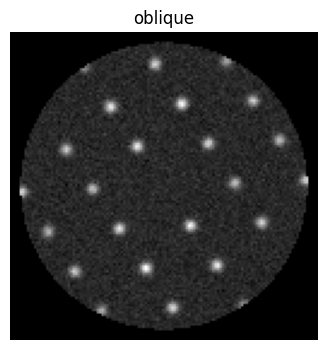

In [38]:
generator = LEEDGenerator(seed=SEED)
image, label_index, metadata = generator(return_metadata=True)

print(f"Label: {metadata['label']} ({label_index})")
print("a_i dot b_j =")
print(np.column_stack([metadata["a1"], metadata["a2"]]).T @ np.column_stack([metadata["b1"], metadata["b2"]]))

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray", origin="lower")
plt.title(metadata["label"])
plt.axis("off");

## Task 3: Training experiment

For the first experiment, the generator is used to create balanced training and test sets. The images are generated once and stored as tensors. This makes the comparison reproducible and keeps the training loop simple.

The training generator is allowed to produce both sparse patterns and patterns with more visible diffraction orders. The test generator is kept closer to realistic LEED images with fewer visible orders. This broadens the training data without making the test set easier.

In [39]:
def make_balanced_leed_dataset(n_per_class, seed, generator_kwargs=None):
    if generator_kwargs is None:
        generator_kwargs = {}

    generator = LEEDGenerator(seed=seed, **generator_kwargs)
    images = []
    labels = []

    for class_name in BRAVAIS_CLASSES:
        for _ in range(n_per_class):
            image, label = generator(label=class_name)
            images.append(image)
            labels.append(label)

    images = np.asarray(images, dtype=np.float32)[:, None, :, :]
    labels = np.asarray(labels, dtype=np.int64)

    return TensorDataset(torch.from_numpy(images), torch.from_numpy(labels))


N_TRAIN_PER_CLASS = 250
N_TEST_PER_CLASS = 60

TRAIN_GENERATOR_SETTINGS = {
    "first_order_radius_range": (8, 20),
    "detector_radius_range": (0.42, 0.50),
}

TEST_GENERATOR_SETTINGS = {
    "first_order_radius_range": (13, 20),
    "detector_radius_range": (0.42, 0.48),
}

train_dataset = make_balanced_leed_dataset(
    N_TRAIN_PER_CLASS,
    seed=SEED + 1,
    generator_kwargs=TRAIN_GENERATOR_SETTINGS,
)
test_dataset = make_balanced_leed_dataset(
    N_TEST_PER_CLASS,
    seed=SEED + 2,
    generator_kwargs=TEST_GENERATOR_SETTINGS,
)

len(train_dataset), len(test_dataset)

(1250, 300)

In [40]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

example_images, example_labels = next(iter(train_loader))
example_images.shape, example_labels.shape

(torch.Size([32, 1, 128, 128]), torch.Size([32]))

The image tensor has shape `(batch_size, 1, 128, 128)`: batch dimension, grayscale channel, and two image dimensions. The labels are integer class indices from `0` to `4`.

In [41]:
model = LEEDBravaisCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

history = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader, criterion)
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "test_loss": test_loss,
            "test_accuracy": test_accuracy,
        }
    )
    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train loss {train_loss:.4f}, train acc {train_accuracy:.3f} | "
        f"test loss {test_loss:.4f}, test acc {test_accuracy:.3f}"
    )

Epoch 01/20 | train loss 1.5395, train acc 0.294 | test loss 2.5527, test acc 0.200
Epoch 02/20 | train loss 1.4869, train acc 0.310 | test loss 1.4639, test acc 0.327
Epoch 03/20 | train loss 1.4603, train acc 0.352 | test loss 1.5011, test acc 0.290
Epoch 04/20 | train loss 1.4439, train acc 0.338 | test loss 1.4737, test acc 0.337
Epoch 05/20 | train loss 1.4305, train acc 0.364 | test loss 1.5518, test acc 0.317
Epoch 06/20 | train loss 1.4305, train acc 0.354 | test loss 1.4281, test acc 0.360
Epoch 07/20 | train loss 1.4214, train acc 0.362 | test loss 1.4291, test acc 0.353
Epoch 08/20 | train loss 1.4125, train acc 0.358 | test loss 1.4368, test acc 0.333
Epoch 09/20 | train loss 1.4028, train acc 0.374 | test loss 1.4222, test acc 0.333
Epoch 10/20 | train loss 1.4053, train acc 0.364 | test loss 1.4779, test acc 0.337
Epoch 11/20 | train loss 1.3923, train acc 0.379 | test loss 1.4008, test acc 0.390
Epoch 12/20 | train loss 1.3934, train acc 0.379 | test loss 1.5455, test ac

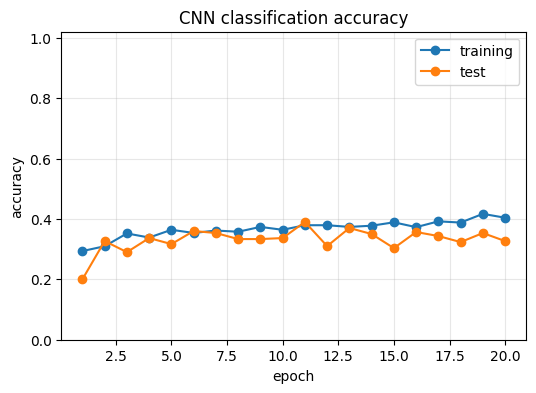

In [42]:
epochs = [entry["epoch"] for entry in history]
train_accuracy = [entry["train_accuracy"] for entry in history]
test_accuracy = [entry["test_accuracy"] for entry in history]

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_accuracy, marker="o", label="training")
plt.plot(epochs, test_accuracy, marker="o", label="test")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.ylim(0, 1.02)
plt.legend()
plt.grid(alpha=0.3)
plt.title("CNN classification accuracy");

### Confusion matrix

The confusion matrix shows which lattice classes are correctly recognized and which classes are confused with each other. Rows correspond to the true class, columns to the predicted class.

In [43]:
@torch.no_grad()
def predict_all(model, dataloader, device=DEVICE):
    model.eval()
    all_predictions = []
    all_labels = []

    for images, labels in dataloader:
        images = images.to(device)
        logits = model(images)
        predictions = logits.argmax(dim=1).cpu()
        all_predictions.append(predictions)
        all_labels.append(labels.cpu())

    return torch.cat(all_predictions), torch.cat(all_labels)


def compute_confusion_matrix(predictions, labels, num_classes=NUM_CLASSES):
    matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for true_label, predicted_label in zip(labels, predictions):
        matrix[true_label, predicted_label] += 1
    return matrix.numpy()


predictions, true_labels = predict_all(model, test_loader)
confusion = compute_confusion_matrix(predictions, true_labels)
confusion

array([[22, 26, 12,  0,  0],
       [12, 47,  1,  0,  0],
       [27,  8, 25,  0,  0],
       [25, 17, 16,  1,  1],
       [20,  3, 34,  0,  3]])

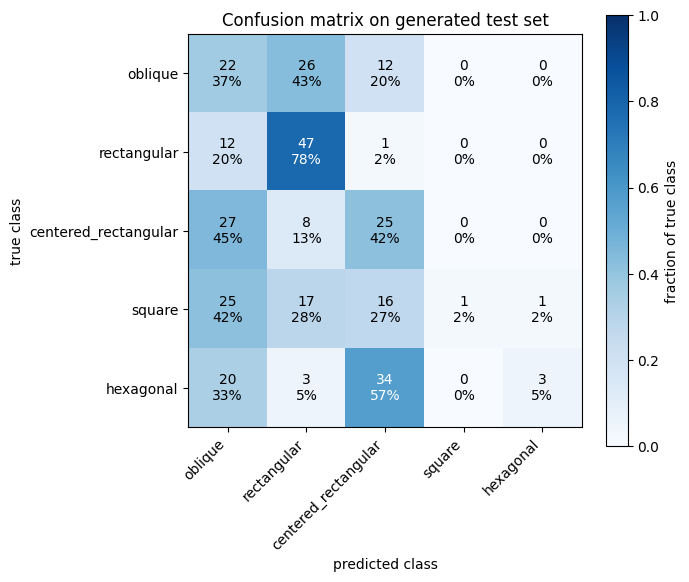

In [44]:
def plot_confusion_matrix(confusion, class_names):
    row_sums = confusion.sum(axis=1, keepdims=True)
    normalized = np.divide(confusion, row_sums, where=row_sums != 0)

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
    fig.colorbar(image, ax=ax, label="fraction of true class")

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("predicted class")
    ax.set_ylabel("true class")
    ax.set_title("Confusion matrix on generated test set")

    for i in range(confusion.shape[0]):
        for j in range(confusion.shape[1]):
            value = normalized[i, j]
            text_color = "white" if value > 0.5 else "black"
            ax.text(j, i, f"{confusion[i, j]}\n{value:.0%}", ha="center", va="center", color=text_color)

    fig.tight_layout()
    return fig, ax


plot_confusion_matrix(confusion, BRAVAIS_CLASSES);